In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
import matplotlib.patheffects as pe

from clim_functions import compute_AR_from_Q, collect_tracking_R, tracking_kdtree, day_plot


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'

dataset = nc.Dataset(fname)

lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))

def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2

dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])

x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


Cleaning.
1. Valid data for both inner- and outer-core data i.e. .dropna()
2. Cyclonicity must match
3. Reasonable values i.e. (Rc <= 300, |w| <= 1e-3), detQ = 1, DOPPIO center must be reasonably close to nencioli center

In [3]:
fp = '/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_DOPPIO_SEACOFS_26yr.pkl'
df_doppio = pd.read_pickle(fp)
df_doppio['w'] *= 1e-3; #df_doppio['Omega0'] *= 1e-3; df_doppio['Omega'] *= 1e-3
df_doppio


,Day,fnumber,nxc,nyc,nCyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R
0,1462,1461,830.0,1515.0,AE,829.879126,1515.297884,0.000016,"[[0.7054724746035225, -0.17299518294950286], [...",0.007219,0.008268,96.456316,-38.462785,63.384028
1,1462,1461,358.0,1408.0,AE,357.902634,1407.794571,0.000032,"[[1.2525415454561337, -0.37318304544145586], [...",0.014587,0.013549,78.042405,-41.260426,50.068171
2,1462,1461,928.0,1356.0,CE,928.181752,1356.070550,-0.000011,"[[0.9184334895938384, -0.6568144522261018], [-...",-0.004380,-0.006890,118.032741,47.992205,74.597458
3,1462,1461,506.0,1354.0,CE,505.750855,1353.499933,-0.000032,"[[1.0915204469734063, -0.17483272531676586], [...",-0.015919,-0.013202,106.666574,75.106895,69.457705
4,1462,1461,754.0,1285.0,AE,753.849693,1284.689807,0.000022,"[[1.300245004042572, -0.37537759847059776], [-...",0.010123,0.008255,103.327517,-44.066805,65.961546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61070,2781,2751,207.0,245.0,CE,NaN,NaN,NaN,"[[nan, nan], [nan, nan]]",NaN,NaN,NaN,NaN,0.000000
61071,2781,2751,277.0,195.0,AE,276.547372,194.862333,0.000043,"[[1.013759577932116, 0.5157684071567346], [0.5...",0.018791,0.023107,50.418231,-29.369515,39.151600
61072,2781,2751,267.0,110.0,CE,267.353496,111.077620,-0.000021,"[[0.5975541084545375, -0.3310726621223537], [-...",-0.008588,-0.009169,64.345801,18.981249,21.430240
61073,2781,2751,134.0,79.0,AE,138.623992,79.127059,0.000020,"[[0.8155891904055363, -0.27287817049903385], [...",0.009196,0.005533,43.869306,-5.324503,22.329446


In [4]:
# --- 1. Drop only required columns ---
df_clean1 = df_doppio.dropna().copy()

print(f'1. Removed {len(df_doppio) - len(df_clean1)} eddy-days')

# --- 2. Cyclonicity match ---
nenc_cyc = np.where(df_clean1['nCyc'].values == 'AE', 1, -1)
doppio_cyc = np.sign(df_clean1['w'].values)

mask = (nenc_cyc == doppio_cyc)
df_clean2 = df_clean1.loc[mask].copy()

print(f'2. Removed {len(df_clean1) - len(df_clean2)} eddy-days')

# --- 3. Thresholds ---
df_clean2['AR'] = compute_AR_from_Q(np.stack(df_clean2['Q'].values))

# --- detQ (vectorised) ---
detQ = df_clean2['Q'].apply(lambda Q: Q[0,0]*Q[1,1] - Q[1,0]**2)

# --- masks ---
realistic_mask = (
    (df_clean2['Rc'].values < 300)
    & (np.abs(df_clean2['w'].values) < 1e-3)
    & (np.abs(df_clean2['AR']) < 8)
)

boundary_mask = (
    (df_clean2['xc'].values > 0)
    & (df_clean2['xc'].values < X_grid.max())
    & (df_clean2['yc'].values > 0)
    & (df_clean2['yc'].values < Y_grid.max())
)

det_mask = np.isclose(detQ, 1, atol=1e-5)

# --- center error ---
err = np.hypot(
    df_clean2['xc'].values - df_clean2['nxc'].values,
    df_clean2['yc'].values - df_clean2['nyc'].values
)
center_mask = err < 20

# --- combine everything at once (faster & cleaner) ---
final_mask = realistic_mask & boundary_mask & det_mask & center_mask

df_clean = df_clean2.loc[final_mask].copy().reset_index(drop=True)

print(f'Total removed: {len(df_clean2) - len(df_clean)} eddy-days')


1. Removed 6301 eddy-days
2. Removed 88 eddy-days
Total removed: 4621 eddy-days


,Day,fnumber,nxc,nyc,nCyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R,AR
0,1462,1461,830.0,1515.0,AE,829.879126,1515.297884,0.000016,"[[0.7054724746035225, -0.17299518294950286], [...",0.007219,0.008268,96.456316,-38.462785,63.384028,1.497688
1,1462,1461,358.0,1408.0,AE,357.902634,1407.794571,0.000032,"[[1.2525415454561337, -0.37318304544145586], [...",0.014587,0.013549,78.042405,-41.260426,50.068171,1.491752
2,1462,1461,928.0,1356.0,CE,928.181752,1356.070550,-0.000011,"[[0.9184334895938384, -0.6568144522261018], [-...",-0.004380,-0.006890,118.032741,47.992205,74.597458,1.969122
3,1462,1461,506.0,1354.0,CE,505.750855,1353.499933,-0.000032,"[[1.0915204469734063, -0.17483272531676586], [...",-0.015919,-0.013202,106.666574,75.106895,69.457705,1.207563
4,1462,1461,754.0,1285.0,AE,753.849693,1284.689807,0.000022,"[[1.300245004042572, -0.37537759847059776], [-...",0.010123,0.008255,103.327517,-44.066805,65.961546,1.519659


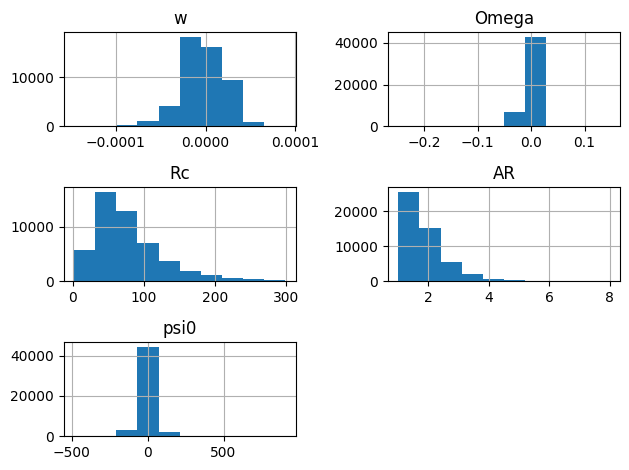

In [5]:
df_clean.hist(['w', 'Omega', 'Rc', 'AR', 'psi0'])
plt.tight_layout()
df_clean.head()


Tracking

In [6]:
df_data = df_clean.copy()
df_data = df_data.rename(columns={'nCyc': 'Cyc'})
df_data['eddy_idx'] = df_data.groupby('Day').cumcount()
df_data


,Day,fnumber,nxc,nyc,Cyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R,AR,eddy_idx
0,1462,1461,830.0,1515.0,AE,829.879126,1515.297884,0.000016,"[[0.7054724746035225, -0.17299518294950286], [...",0.007219,0.008268,96.456316,-38.462785,63.384028,1.497688,0
1,1462,1461,358.0,1408.0,AE,357.902634,1407.794571,0.000032,"[[1.2525415454561337, -0.37318304544145586], [...",0.014587,0.013549,78.042405,-41.260426,50.068171,1.491752,1
2,1462,1461,928.0,1356.0,CE,928.181752,1356.070550,-0.000011,"[[0.9184334895938384, -0.6568144522261018], [-...",-0.004380,-0.006890,118.032741,47.992205,74.597458,1.969122,2
3,1462,1461,506.0,1354.0,CE,505.750855,1353.499933,-0.000032,"[[1.0915204469734063, -0.17483272531676586], [...",-0.015919,-0.013202,106.666574,75.106895,69.457705,1.207563,3
4,1462,1461,754.0,1285.0,AE,753.849693,1284.689807,0.000022,"[[1.300245004042572, -0.37537759847059776], [-...",0.010123,0.008255,103.327517,-44.066805,65.961546,1.519659,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50060,2781,2751,237.0,297.0,CE,240.987166,298.839719,-0.000032,"[[0.6179970315770097, -0.26818038366846564], [...",-0.013619,-0.018552,24.129200,5.400512,6.532454,1.795583,21
50061,2781,2751,277.0,195.0,AE,276.547372,194.862333,0.000043,"[[1.013759577932116, 0.5157684071567346], [0.5...",0.018791,0.023107,50.418231,-29.369515,39.151600,1.660288,22
50062,2781,2751,267.0,110.0,CE,267.353496,111.077620,-0.000021,"[[0.5975541084545375, -0.3310726621223537], [-...",-0.008588,-0.009169,64.345801,18.981249,21.430240,1.938649,23
50063,2781,2751,134.0,79.0,AE,138.623992,79.127059,0.000020,"[[0.8155891904055363, -0.27287817049903385], [...",0.009196,0.005533,43.869306,-5.324503,22.329446,1.437197,24


Optimal R = 1

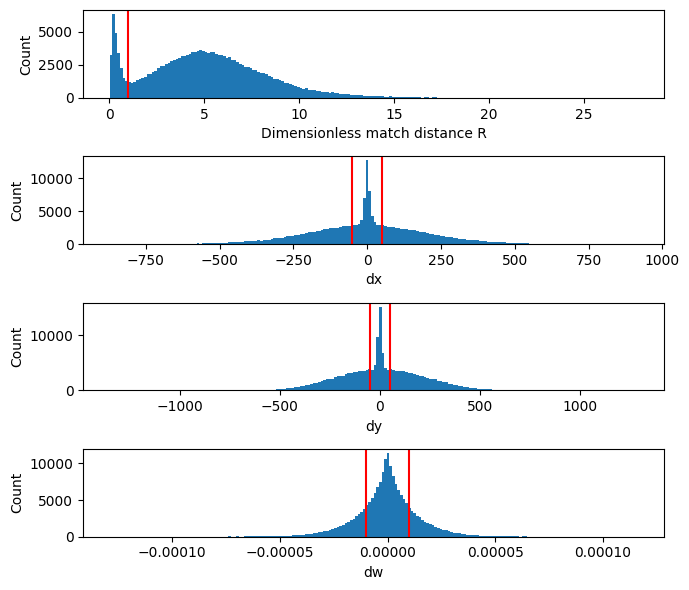

In [7]:
df = df_data[df_data.Day <= df_data.Day.min() + 1000]
df_R = collect_tracking_R(
    df,
    L_SCALE=50,
    W_SCALE=1e-5,
    LOOKBACK=4
)

fig, axes = plt.subplots(4, 1, figsize=(7, 6), sharex=False)

# R
axes[0].hist(df_R['R'], bins=200)
axes[0].axvline(1, color='r')
axes[0].set_xlabel('Dimensionless match distance R')
axes[0].set_ylabel('Count')

# dx
axes[1].hist(df_R['dx'], bins=200)
axes[1].axvline(-50, color='r')
axes[1].axvline(50, color='r')
axes[1].set_xlabel('dx')
axes[1].set_ylabel('Count')

# dy
axes[2].hist(df_R['dy'], bins=200)
axes[2].axvline(-50, color='r')
axes[2].axvline(50, color='r')
axes[2].set_xlabel('dy')
axes[2].set_ylabel('Count')

# dw
axes[3].hist(df_R['dw'], bins=200)
axes[3].axvline(-1e-5, color='r')
axes[3].axvline(1e-5, color='r')
axes[3].set_xlabel('dw')
axes[3].set_ylabel('Count')

plt.tight_layout()
plt.show()


Tracking

In [8]:
df = df_data.copy()#[df_data.Day <= df_data.Day.min() + 200]

start_ID = np.arange(len(df[df.Day==df.Day.min()]))
next_num = np.max(start_ID) + 1

df_tracked = tracking_kdtree(
    df,
    start_ID=start_ID,
    next_num=next_num,
    L_SCALE=50,
    W_SCALE=1e-5,
    R_THRESH=1, 
    LOOKBACK=4
)


Day 1600, elapsed: 20.96s
Day 1800, elapsed: 66.09s
Day 2000, elapsed: 100.41s
Day 2200, elapsed: 140.12s
Day 2400, elapsed: 172.45s
Day 2600, elapsed: 216.02s


In [9]:
df_tracked


,Day,fnumber,nxc,nyc,Cyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R,AR,eddy_idx,Eddy,next_num
0,1462,1461,830.0,1515.0,AE,829.879126,1515.297884,0.000016,"[[0.7054724746035225, -0.17299518294950286], [...",0.007219,0.008268,96.456316,-38.462785,63.384028,1.497688,0,0,12580
1,1462,1461,358.0,1408.0,AE,357.902634,1407.794571,0.000032,"[[1.2525415454561337, -0.37318304544145586], [...",0.014587,0.013549,78.042405,-41.260426,50.068171,1.491752,1,1,12580
2,1462,1461,928.0,1356.0,CE,928.181752,1356.070550,-0.000011,"[[0.9184334895938384, -0.6568144522261018], [-...",-0.004380,-0.006890,118.032741,47.992205,74.597458,1.969122,2,2,12580
3,1462,1461,506.0,1354.0,CE,505.750855,1353.499933,-0.000032,"[[1.0915204469734063, -0.17483272531676586], [...",-0.015919,-0.013202,106.666574,75.106895,69.457705,1.207563,3,3,12580
4,1462,1461,754.0,1285.0,AE,753.849693,1284.689807,0.000022,"[[1.300245004042572, -0.37537759847059776], [-...",0.010123,0.008255,103.327517,-44.066805,65.961546,1.519659,4,4,12580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50060,2781,2751,237.0,297.0,CE,240.987166,298.839719,-0.000032,"[[0.6179970315770097, -0.26818038366846564], [...",-0.013619,-0.018552,24.129200,5.400512,6.532454,1.795583,21,12579,12580
50061,2781,2751,277.0,195.0,AE,276.547372,194.862333,0.000043,"[[1.013759577932116, 0.5157684071567346], [0.5...",0.018791,0.023107,50.418231,-29.369515,39.151600,1.660288,22,11320,12580
50062,2781,2751,267.0,110.0,CE,267.353496,111.077620,-0.000021,"[[0.5975541084545375, -0.3310726621223537], [-...",-0.008588,-0.009169,64.345801,18.981249,21.430240,1.938649,23,12546,12580
50063,2781,2751,134.0,79.0,AE,138.623992,79.127059,0.000020,"[[0.8155891904055363, -0.27287817049903385], [...",0.009196,0.005533,43.869306,-5.324503,22.329446,1.437197,24,12554,12580


In [10]:
# path = '/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_tracked.pkl'
# df_tracked.to_pickle(path)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


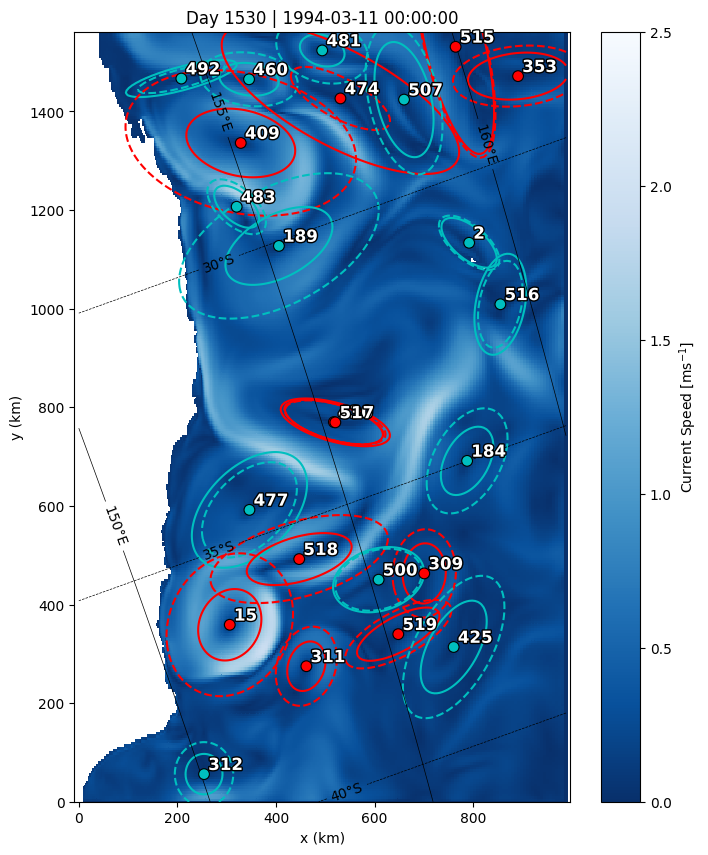

In [18]:
day_plot(1530, df_tracked)
